# 04 - EVALUATION

Mục tiêu:
- Đánh giá mô hình Random Forest Tuned
- Tính các chỉ số MAE, MSE, RMSE, R²
- Kiểm tra sai số dự đoán
- Chuẩn bị mô hình cuối cùng để đóng gói


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Import thư viện thành công!")

Import thư viện thành công!


In [3]:
df = pd.read_csv("/content/winequality-red.csv")

# Xóa dữ liệu trùng
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Dataset: (1359, 12)
X_train: (1087, 11)
X_test: (272, 11)


In [4]:
final_model = Pipeline([
    ("preprocess", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=2,
        random_state=42
    ))
])

print("Đã tạo mô hình Random Forest Tuned.")

Đã tạo mô hình Random Forest Tuned.


In [5]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("===== KẾT QUẢ ĐÁNH GIÁ =====")
print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

===== KẾT QUẢ ĐÁNH GIÁ =====
MAE  : 0.468880
MSE  : 0.379509
RMSE : 0.616043
R²   : 0.464240


In [6]:
# Tạo bảng so sánh giá trị thực tế và giá trị dự đoán

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.head(10)

,Actual,Predicted,Error
0,5,5.036182,-0.036182
1,6,5.961964,0.038036
2,7,6.407513,0.592487
3,5,5.464959,-0.464959
4,4,5.403688,-1.403688
5,7,6.781710,0.218290
6,5,5.579163,-0.579163
7,5,5.155002,-0.155002
8,6,5.928203,0.071797
9,5,5.516656,-0.516656


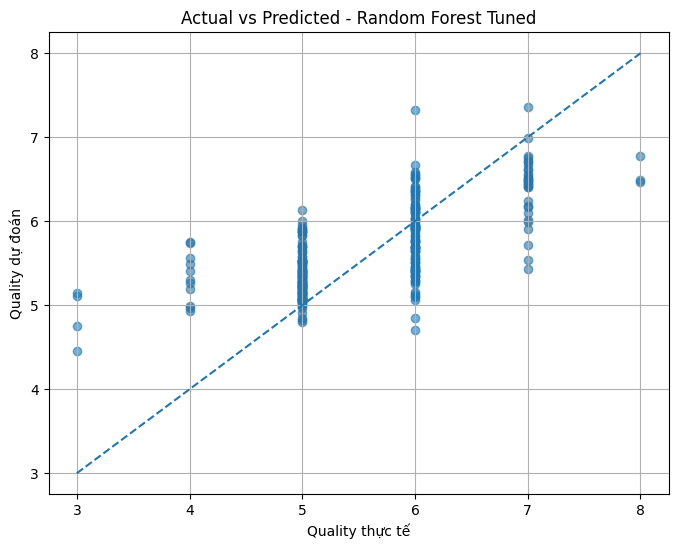

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Đường dự đoán hoàn hảo
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Quality thực tế")
plt.ylabel("Quality dự đoán")
plt.title("Actual vs Predicted - Random Forest Tuned")
plt.grid(True)

plt.show()

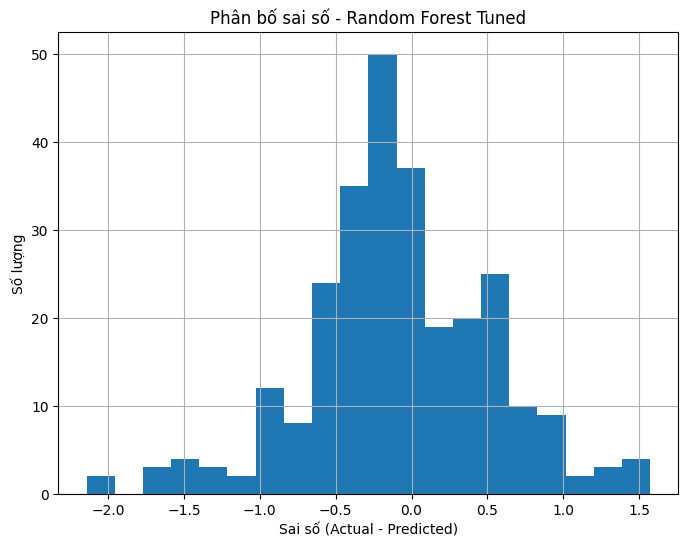

In [8]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.hist(errors, bins=20)

plt.xlabel("Sai số (Actual - Predicted)")
plt.ylabel("Số lượng")
plt.title("Phân bố sai số - Random Forest Tuned")
plt.grid(True)

plt.show()

## Kết luận

Mô hình được lựa chọn là Random Forest Regressor với các tham số:

- n_estimators = 200
- max_depth = 10
- min_samples_split = 2
- random_state = 42

Kết quả đánh giá trên tập test:

- MAE = 0.468880
- MSE = 0.379509
- RMSE = 0.616043
- R² = 0.464240

Mô hình được sử dụng làm mô hình cuối cùng để đóng gói và triển khai.

In [9]:
print("Kiểu model:")
print(type(final_model))

print("\nModel:")
print(final_model)

Kiểu model:
<class 'sklearn.pipeline.Pipeline'>

Model:
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       random_state=42))])


In [10]:
print(final_model.named_steps)

{'preprocess': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]), 'model': RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)}


In [11]:
import os

os.makedirs("/content/models", exist_ok=True)

print("Đã tạo /content/models")

Đã tạo /content/models


In [12]:
import joblib

model_path = "/content/models/model.joblib"

joblib.dump(final_model, model_path)

print("Đã lưu model.joblib")
print("Đường dẫn:", model_path)

Đã lưu model.joblib
Đường dẫn: /content/models/model.joblib


In [13]:
import os

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Kích thước model: {size_mb:.2f} MB")

Kích thước model: 4.17 MB


In [14]:
loaded_model = joblib.load("/content/models/model.joblib")

print("Load model thành công!")
print(loaded_model)

Load model thành công!
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       random_state=42))])


In [15]:
pred_loaded = loaded_model.predict(X_test)

print("5 dự đoán đầu tiên:")
print(pred_loaded[:5])

5 dự đoán đầu tiên:
[5.03618208 5.96196391 6.40751274 5.46495865 5.40368776]


In [16]:
import numpy as np

pred_original = final_model.predict(X_test)
pred_loaded = loaded_model.predict(X_test)

print(
    "Kết quả giống nhau:",
    np.allclose(pred_original, pred_loaded)
)

Kết quả giống nhau: True


In [17]:
import sklearn
import numpy
import pandas

print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

scikit-learn: 1.6.1
numpy: 2.1.3
pandas: 2.2.3


In [18]:
import json

feature_names = list(X.columns)

schema = {
    "task": "regression",
    "target": "quality",
    "features": []
}

for col in feature_names:
    schema["features"].append({
        "name": col,
        "dtype": str(X[col].dtype),
        "min": float(X[col].min()),
        "max": float(X[col].max())
    })

schema_path = "/content/models/schema.json"

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print("Đã tạo schema.json")

Đã tạo schema.json


In [19]:
print(json.dumps(schema, indent=2, ensure_ascii=False))

{
  "task": "regression",
  "target": "quality",
  "features": [
    {
      "name": "fixed acidity",
      "dtype": "float64",
      "min": 4.6,
      "max": 15.9
    },
    {
      "name": "volatile acidity",
      "dtype": "float64",
      "min": 0.12,
      "max": 1.58
    },
    {
      "name": "citric acid",
      "dtype": "float64",
      "min": 0.0,
      "max": 1.0
    },
    {
      "name": "residual sugar",
      "dtype": "float64",
      "min": 0.9,
      "max": 15.5
    },
    {
      "name": "chlorides",
      "dtype": "float64",
      "min": 0.012,
      "max": 0.611
    },
    {
      "name": "free sulfur dioxide",
      "dtype": "float64",
      "min": 1.0,
      "max": 72.0
    },
    {
      "name": "total sulfur dioxide",
      "dtype": "float64",
      "min": 6.0,
      "max": 289.0
    },
    {
      "name": "density",
      "dtype": "float64",
      "min": 0.99007,
      "max": 1.00369
    },
    {
      "name": "pH",
      "dtype": "float64",
      "min": 2.74,


In [20]:
with open("/content/models/schema.json", "r", encoding="utf-8") as f:
    loaded_schema = json.load(f)

print("Số feature:", len(loaded_schema["features"]))
print("Target:", loaded_schema["target"])

print("\nDanh sách feature:")
for feature in loaded_schema["features"]:
    print("-", feature["name"])

Số feature: 11
Target: quality

Danh sách feature:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


In [21]:
import json
import sklearn
import numpy
import pandas
from datetime import datetime

metadata = {
    "model_name": "Random Forest Regressor",
    "model_version": "1.0.0",
    "task": "regression",
    "target": "quality",

    "metrics": {
        "MAE": 0.468880,
        "MSE": 0.379509,
        "RMSE": 0.616043,
        "R2": 0.464240
    },

    "best_parameters": {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 2
    },

    "dataset": {
        "name": "Red Wine Quality",
        "rows_after_duplicate_removal": int(len(df)),
        "number_of_features": len(X.columns)
    },

    "libraries": {
        "scikit_learn": sklearn.__version__,
        "numpy": numpy.__version__,
        "pandas": pandas.__version__
    },

    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

metadata_path = "/content/models/metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Đã tạo metadata.json")

Đã tạo metadata.json


In [22]:
import os

files = [
    "/content/models/model.joblib",
    "/content/models/schema.json",
    "/content/models/metadata.json"
]

print("===== KIỂM TRA PACKAGE =====")

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"✅ {os.path.basename(file)} - {size:.2f} KB")
    else:
        print(f"❌ Thiếu: {os.path.basename(file)}")

===== KIỂM TRA PACKAGE =====
✅ model.joblib - 4274.89 KB
✅ schema.json - 1.20 KB
✅ metadata.json - 0.57 KB


In [23]:
!ls -lh /content/models/

total 4.2M
-rw-r--r-- 1 root root  582 Sep 23 21:04 metadata.json
-rw-r--r-- 1 root root 4.2M Sep 23 21:02 model.joblib
-rw-r--r-- 1 root root 1.3K Sep 23 21:03 schema.json


In [24]:
from google.colab import files

files.download("/content/models/model.joblib")
files.download("/content/models/schema.json")
files.download("/content/models/metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>